In [459]:
import polars as pl
import pandas as pd
from indicators.types import IndicatorConfig, IndicatorType
from indicators.momento import RSIIndicator, StochasticOscillatorIndicator, CCIIndicator
from indicators.volatilidade import ATRIndicator, BollingerBandsIndicator, DonchianChannelIndicator
from indicators.tendencia import IchimokuCloudIndicator
from indicators.volume import MFIIndicator, OBVIndicator, VWAPIndicator
from indicators.medias_moveis import ADXIndicator, EMAIndicator, SMAIndicator, MACDIndicator

from data_loader.loader import DataLoader

from backtesting import Backtest, Strategy
import optuna
from optuna.exceptions import TrialPruned

import numpy as np
import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import TimeLimit
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback


In [460]:
df = pl.read_parquet("data/AAPL_5minute.parquet")
df.head()

open,high,low,close,volume,date
f64,f64,f64,f64,f64,datetime[ns]
77.465,77.465,77.465,77.465,6404.0,2020-05-18 08:00:00
77.5275,77.54,77.5275,77.54,3716.0,2020-05-18 08:05:00
77.55,77.55,77.55,77.55,2012.0,2020-05-18 08:10:00
77.6825,77.6825,77.6825,77.6825,1040.0,2020-05-18 08:15:00
77.6075,77.6075,77.6075,77.6075,400.0,2020-05-18 08:20:00


In [461]:
def preprocess_with_indicators(path: str, indicadores: list[IndicatorConfig]) -> pl.DataFrame:
    # 1) Lazy load + limpezas básicas (usar with_columns para tudo)
    df = (
        pl.scan_parquet(path)  # Alterado de read_parquet para scan_parquet
          .sort("date")
          .fill_null(strategy="forward")
          .fill_null(0.0)
          .with_columns([
              pl.col(c).log().alias(f"{c}_log")
              for c in ["open", "high", "low", "close"]
          ])
          .collect()
    )

    # 2) Adiciona indicadores via DataLoader
    dl = DataLoader()
    df = dl.add_technical_indicators(df, indicators_to_add=indicadores)

    # 3) Reaplica fill_null para cobrir NaNs iniciais dos indicadores
    df = df.fill_null(strategy="forward").fill_null(0.0)

    return df

Pre-processamento

In [462]:
indicadores = [
    # Momento
    IndicatorConfig(IndicatorType.RSI, params=[14]),
    IndicatorConfig(IndicatorType.STOCH, params=[14, 3]), # k_period, d_period, slowing_k_period
    IndicatorConfig(IndicatorType.CCI, params=[20]),

    # Volatilidade
    IndicatorConfig(IndicatorType.BB, params=[20, 2]), # period, num_std_devs
    IndicatorConfig(IndicatorType.DONCHIAN, params=[20]), # n_periods
    # IndicatorConfig(IndicatorType.ROC, params=[12]), # Você removeu ROCIndicator da importação

    # Tendência
    IndicatorConfig(IndicatorType.ICHIMOKU, params=[9, 26, 52]), # tenkan_sen_period, kijun_sen_period, senkou_span_b_period

    # Volume
    IndicatorConfig(IndicatorType.MFI, params=[14]), # n_periods
    IndicatorConfig(IndicatorType.OBV, params=[]),
    IndicatorConfig(IndicatorType.VWAP, params=[14]),

    # Médias Móveis
    IndicatorConfig(IndicatorType.ADX, params=[14]), # n_periods
    IndicatorConfig(IndicatorType.EMA, params=[20]), # n_periods
    IndicatorConfig(IndicatorType.SMA, params=[50]), # n_periods
    IndicatorConfig(IndicatorType.MACD, params=[12, 26, 9]) # fast_period, slow_period, signal_period
]

In [463]:
path = "/workspaces/VIII-Desafio-de-Ciencia-de-Dados/data/AAPL_5minute.parquet"
df = preprocess_with_indicators(path, indicadores)

Erro ao adicionar indicador obv: 'Expr' object has no attribute 'cumsum'


In [464]:
df

open,high,low,close,volume,date,open_log,high_log,low_log,close_log,rsi_14,StochK_14_3,StochD_14_3,CCI_20,BB_Middle_20,BB_Upper_20,BB_Lower_20,DC_Upper_20,DC_Lower_20,DC_Middle_20,TENKAN_9,KIJUN_26,SENKOU_A_9_26,SENKOU_B_52,CHIKOU_26,MFI_14,VWAP_14,ADX_14,+DI_14,-DI_14,ema_20,sma_50,macd_line,macd_signal,macd_hist
f64,f64,f64,f64,f64,datetime[ns],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
77.465,77.465,77.465,77.465,6404.0,2020-05-18 08:00:00,4.349826,4.349826,4.349826,4.349826,40.240455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.2525,100.0,0.0,0.125604,0.0,0.0,77.465,0.0,0.0,0.0,0.0
77.5275,77.54,77.5275,77.54,3716.0,2020-05-18 08:05:00,4.350633,4.350794,4.350633,4.350794,40.240455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.235,100.0,0.0,0.125604,0.0,0.0,77.472143,0.0,0.001683,0.000935,0.000748
77.55,77.55,77.55,77.55,2012.0,2020-05-18 08:10:00,4.350923,4.350923,4.350923,4.350923,40.240455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.29,100.0,0.0,0.125604,0.0,0.0,77.479558,0.0,0.002454,0.001558,0.000897
77.6825,77.6825,77.6825,77.6825,1040.0,2020-05-18 08:15:00,4.35263,4.35263,4.35263,4.35263,40.240455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.3775,100.0,0.0,0.125604,0.0,0.0,77.498886,0.0,0.007529,0.00358,0.003948
77.6075,77.6075,77.6075,77.6075,400.0,2020-05-18 08:20:00,4.351664,4.351664,4.351664,4.351664,40.240455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.3125,100.0,0.0,0.125604,0.0,0.0,77.50923,0.0,0.007143,0.00464,0.002503
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
126.7207,126.87,126.0625,126.1263,4.55504e6,2020-08-24 14:20:00,4.841985,4.843163,4.836778,4.837284,40.866356,28.192741,34.908636,-106.085727,127.47538,129.694242,125.256518,128.995,125.0,126.9975,126.86265,126.9975,127.743125,126.655,125.3663,31.907138,127.031971,42.810667,12.818484,27.344818,127.138308,127.725502,-0.52598,-0.33787,-0.18811
126.0775,126.125,125.7,125.7225,3.676124e6,2020-08-24 14:25:00,4.836897,4.837273,4.833898,4.834077,38.461747,18.085106,29.798081,-128.569286,127.342755,129.650518,125.034992,128.995,125.0,126.9975,126.43,126.9975,127.59125,126.6925,125.3663,30.930027,126.987622,42.716426,12.290347,29.721681,127.003469,127.709152,-0.570031,-0.384302,-0.185729
125.7048,125.9425,125.2901,125.4088,3.94402e6,2020-08-24 14:30:00,4.833936,4.835825,4.830632,4.831579,36.65719,10.232791,18.836879,-128.902403,127.19632,129.607662,124.784978,128.995,125.0,126.9975,126.0875,126.9975,127.63625,127.46375,125.3663,29.987327,126.931466,43.014191,11.508854,31.826875,126.851596,127.680478,-0.623073,-0.432056,-0.191016


In [465]:
print(df.shape)
print(df.columns)


(12237, 35)
['open', 'high', 'low', 'close', 'volume', 'date', 'open_log', 'high_log', 'low_log', 'close_log', 'rsi_14', 'StochK_14_3', 'StochD_14_3', 'CCI_20', 'BB_Middle_20', 'BB_Upper_20', 'BB_Lower_20', 'DC_Upper_20', 'DC_Lower_20', 'DC_Middle_20', 'TENKAN_9', 'KIJUN_26', 'SENKOU_A_9_26', 'SENKOU_B_52', 'CHIKOU_26', 'MFI_14', 'VWAP_14', 'ADX_14', '+DI_14', '-DI_14', 'ema_20', 'sma_50', 'macd_line', 'macd_signal', 'macd_hist']


In [466]:
df.select([pl.count().alias("nulos")]).to_pandas()
df.describe().to_pandas()


/tmp/ipykernel_75689/1787464151.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  df.select([pl.count().alias("nulos")]).to_pandas()


,statistic,open,high,low,close,volume,date,open_log,high_log,low_log,...,MFI_14,VWAP_14,ADX_14,+DI_14,-DI_14,ema_20,sma_50,macd_line,macd_signal,macd_hist
0,count,12237.000000,12237.000000,12237.000000,12237.000000,1.223700e+04,12237,12237.000000,12237.000000,12237.000000,...,12237.000000,12237.000000,12237.000000,12237.000000,12237.000000,12237.000000,12237.000000,12237.000000,12237.000000,12237.000000
1,null_count,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,mean,94.741907,94.817138,94.665434,94.744799,7.861988e+05,2020-07-06 09:55:05.295415,4.543178,4.543967,4.542375,...,52.956123,94.634650,25.745265,25.550354,24.876254,94.706643,94.334696,0.028487,0.028654,-0.000167
3,std,12.179279,12.192367,12.165911,12.180137,1.277076e+06,None,0.125314,0.125353,0.125274,...,21.200608,12.540257,11.404471,11.425178,10.644640,12.153181,13.462884,0.160207,0.151714,0.045206
4,min,77.150000,77.150000,77.117500,77.150000,4.000000e+02,2020-05-18 08:00:00,4.345752,4.345752,4.345330,...,0.650720,0.000000,0.125604,0.000000,0.000000,77.346685,0.000000,-0.711761,-0.653422,-0.346180
5,25%,85.787500,85.867500,85.717500,85.795000,1.036400e+04,2020-06-11 14:55:00,4.451873,4.452805,4.451057,...,38.175310,85.738816,17.389713,17.598803,17.701319,85.699598,85.570092,-0.046030,-0.044047,-0.021998
6,50%,92.815000,92.962500,92.745000,92.820000,8.727600e+04,2020-07-07 17:10:00,4.530608,4.532196,4.529854,...,53.162212,92.717835,23.609731,23.575316,23.130391,92.781414,92.738244,0.024428,0.024402,-0.001133
7,75%,99.442500,99.512500,99.337500,99.442500,1.207604e+06,2020-07-30 18:45:00,4.599580,4.600283,4.598523,...,67.970621,99.312133,31.562933,31.009591,30.287785,99.160764,99.005180,0.101911,0.098855,0.021448
8,max,128.762500,128.995000,128.579500,128.787500,2.500762e+07,2020-08-24 14:40:00,4.857970,4.859774,4.856547,...,100.000000,128.450586,73.881747,88.981632,81.194503,128.310313,127.811426,1.433748,1.323664,0.497855


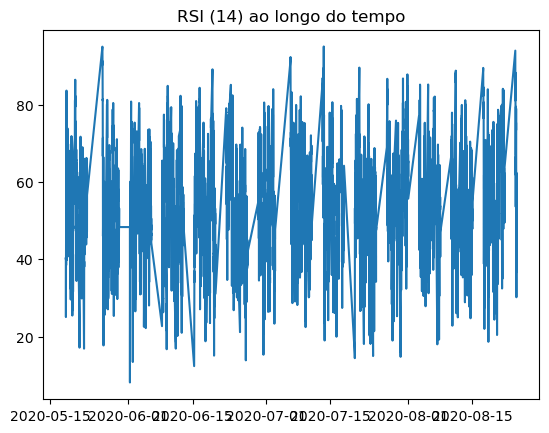

In [467]:
import matplotlib.pyplot as plt
plt.plot(df["date"], df["rsi_14"])
plt.title("RSI (14) ao longo do tempo")
plt.show()


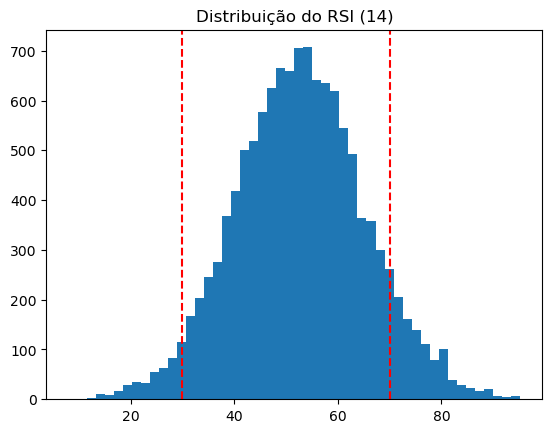

In [468]:
plt.hist(df["rsi_14"], bins=50)
plt.axvline(30, color="r", linestyle="--")
plt.axvline(70, color="r", linestyle="--")
plt.title("Distribuição do RSI (14)")
plt.show()


O histograma mostra um RSI bem “gaussiano” em torno dos 50, com quase toda a massa entre 30 e 70 — ou seja, sinais de sobrecompra/sobrevenda (<30/>70) são relativamente raros.


In [469]:
total = len(df)
oversold = (df["rsi_14"] < 30).sum()
overbought = (df["rsi_14"] > 70).sum()

print(f"Oversold (<30): {oversold} barras — {oversold/total:.2%}")
print(f"Overbought (>70): {overbought} barras — {overbought/total:.2%}")


Oversold (<30): 390 barras — 3.19%
Overbought (>70): 1044 barras — 8.53%


Tentando suavizar o RSI, transformando para 5 minutuos

In [470]:
df = df.with_columns([
    pl.col("rsi_14")
      .rolling_mean(window_size=5)
      .alias("RSI_smooth")
])


In [471]:
total = len(df)
os_s = (df["RSI_smooth"] < 30).sum()
ob_s = (df["RSI_smooth"] > 70).sum()
print(f"Oversold_smooth: {os_s} barras — {os_s/total:.2%}")
print(f"Overbought_smooth: {ob_s} barras — {ob_s/total:.2%}")


Oversold_smooth: 284 barras — 2.32%
Overbought_smooth: 941 barras — 7.69%


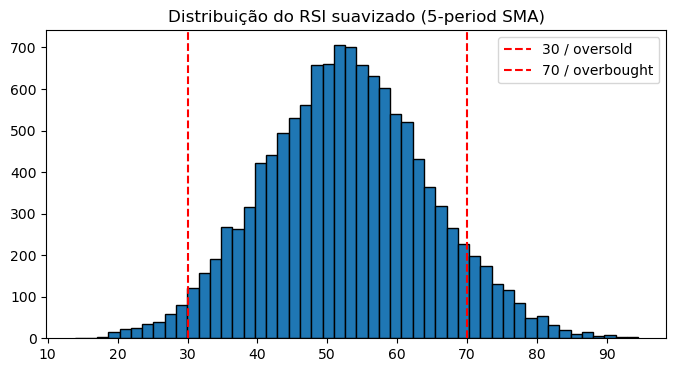

In [472]:
import matplotlib.pyplot as plt

# converte para pandas (se ainda não for)
rsi_s = df["RSI_smooth"].to_pandas()

plt.figure(figsize=(8,4))
plt.hist(rsi_s, bins=50, edgecolor="k")
plt.axvline(30, color="r", linestyle="--", label="30 / oversold")
plt.axvline(70, color="r", linestyle="--", label="70 / overbought")
plt.title("Distribuição do RSI suavizado (5-period SMA)")
plt.legend()
plt.show()


In [473]:

# --- Função de backtest para indicadores --- #
def backtest_indicators(df, indicators):
    results = []
    df_bt = df.rename(columns={'open':'Open','high':'High','low':'Low','close':'Close'}) \
              .dropna(subset=['Open','High','Low','Close'])

    class IndicatorStrategy(Strategy):
        def init(self):
            self.ind = self.I(lambda d: d[self.name], self.data.df)
        def next(self):
            if not self.position and self.ind[-1] < self.buy_thr:
                self.buy()
            elif self.position and self.ind[-1] > self.sell_thr:
                self.position.close()

    for name, thr in indicators.items():
        Strat = type(f"Strat_{name}", (IndicatorStrategy,),
                     {"name": name, "buy_thr": thr['buy_thr'], "sell_thr": thr['sell_thr']})
        bt = Backtest(df_bt, Strat, cash=100_000, commission=0.001, trade_on_close=True)
        stats = bt.run()
        bt.plot()  # Adicionado para plotar o gráfico da estratégia
        results.append({
            'indicator': name,
            'Return [%]': stats['Return [%]'],
            'Sharpe': stats['Sharpe Ratio']
        })
    return pd.DataFrame(results).set_index('indicator')


# Análise de Correlação entre Indicadores

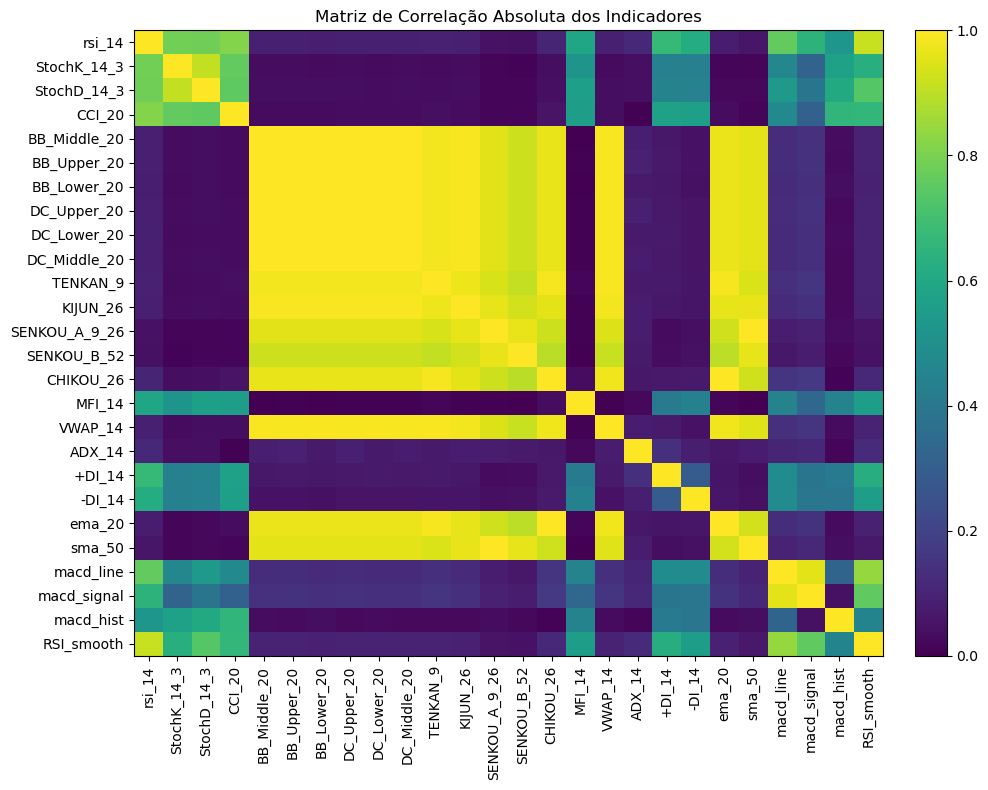


73 pares com |corr| > 0.95:
             feat1          feat2      corr
98   BB_Middle_20   DC_Middle_20  0.999885
116   BB_Upper_20    DC_Upper_20  0.999878
155   DC_Upper_20   DC_Middle_20  0.999705
172   DC_Lower_20   DC_Middle_20  0.999699
96   BB_Middle_20    DC_Upper_20  0.999687
..            ...            ...       ...
191  DC_Middle_20  SENKOU_A_9_26  0.955179
140   BB_Lower_20  SENKOU_A_9_26  0.955155
175   DC_Lower_20  SENKOU_A_9_26  0.954933
158   DC_Upper_20  SENKOU_A_9_26  0.954855
121   BB_Upper_20  SENKOU_A_9_26  0.954666

[73 rows x 3 columns]
Colunas removidas: ['DC_Middle_20', 'DC_Upper_20', 'BB_Upper_20', 'BB_Lower_20', 'DC_Lower_20', 'ema_20', 'sma_50', 'VWAP_14', 'KIJUN_26', 'CHIKOU_26', 'TENKAN_9', 'SENKOU_B_52', 'SENKOU_A_9_26', 'macd_signal']
Forma original: (12237, 36)
Forma reduzida: (12237, 22)


In [474]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Lista de colunas de indicador, como antes
exclude = {
    'open','high','low','close','volume','date',
    'open_log','high_log','low_log','close_log'
}
ind_cols = [c for c in df.columns if c not in exclude]

# --- 2) Converta só o pedaço de indicadores para pandas
pd_ind = df[ind_cols].to_pandas()

# --- 3) Calcule correlação absoluta
corr = pd_ind.corr().abs()

# --- 4) Plote o heatmap
plt.figure(figsize=(max(10, corr.shape[1]*0.3), max(8, corr.shape[0]*0.3)))
plt.imshow(corr, vmin=0, vmax=1, aspect='auto')
plt.colorbar(fraction=0.046, pad=0.04)
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.index)
plt.title("Matriz de Correlação Absoluta dos Indicadores")
plt.tight_layout()
plt.show()

# --- 5) Extraia pares com |corr| > thresh
thresh = 0.95
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
high_corr = (
    corr.where(mask)         # zera abaixo da diagonal
        .stack()             # empilha (i,j) e valor
        .reset_index(name='corr')
        .rename(columns={'level_0':'feat1','level_1':'feat2'})
)
high_corr = high_corr[high_corr['corr'] > thresh] \
            .sort_values('corr', ascending=False)

print(f"\n{len(high_corr)} pares com |corr| > {thresh}:\n", high_corr)

# --- 6) Drop automático das segundas colunas de cada par
# supondo que `to_drop` é um set ou lista de strings
cols_to_drop = high_corr['feat2'].unique().tolist()  # pega cada indicador redundante apenas uma vez

# abordagem 1: usando Polars .drop()
df_reduzido = df.drop(cols_to_drop)

# OU, se preferir via select:
# df_reduzido = df.select([c for c in df.columns if c not in cols_to_drop])

print("Colunas removidas:", cols_to_drop)
print("Forma original:", df.shape)
print("Forma reduzida:", df_reduzido.shape)

In [475]:
# Exemplo de comparação – ajuste thresholds conforme sua convenção
indicator_thresholds = {
    'rsi_14':    {'buy_thr': 30,  'sell_thr': 70},
    'CCI_20':    {'buy_thr': -100,'sell_thr': 100},
}

# 1) Converte todo o Polars DataFrame original pra pandas
pdf_full = df.to_pandas()
pdf_full['date'] = pd.to_datetime(pdf_full['date'])
pdf_full.set_index('date', inplace=True)

# 2) Converte também o df_reduzido
pdf_reduced = df_reduzido.to_pandas()
pdf_reduced['date'] = pd.to_datetime(pdf_reduced['date'])
pdf_reduced.set_index('date', inplace=True)

# 3) Agora chame backtest_indicators usando esses pandas DataFrames
summary_full    = backtest_indicators(pdf_full,    indicator_thresholds)
summary_reduced = backtest_indicators(pdf_reduced, indicator_thresholds)

print("=== Backtest Completo ===")
print(summary_full)
print("\n=== Backtest Reduzido ===")
print(summary_reduced)


Backtest.run:   0%|          | 0/12236 [00:00<?, ?bar/s]

/opt/conda/lib/python3.12/site-packages/backtesting/_plotting.py:141: UserWarning: Data contains too many candlesticks to plot; downsampling to '15min'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "


Backtest.run:   0%|          | 0/12236 [00:00<?, ?bar/s]

/opt/conda/lib/python3.12/site-packages/backtesting/_plotting.py:141: UserWarning: Data contains too many candlesticks to plot; downsampling to '15min'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "


Backtest.run:   0%|          | 0/12236 [00:00<?, ?bar/s]

/opt/conda/lib/python3.12/site-packages/backtesting/_plotting.py:141: UserWarning: Data contains too many candlesticks to plot; downsampling to '15min'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "


Backtest.run:   0%|          | 0/12236 [00:00<?, ?bar/s]

/opt/conda/lib/python3.12/site-packages/backtesting/_plotting.py:141: UserWarning: Data contains too many candlesticks to plot; downsampling to '15min'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "


=== Backtest Completo ===
           Return [%]    Sharpe
indicator                      
rsi_14       7.138645  1.145254
CCI_20     -16.958402 -5.353382

=== Backtest Reduzido ===
           Return [%]    Sharpe
indicator                      
rsi_14       7.138645  1.145254
CCI_20     -16.958402 -5.353382


# Treinamento DRL

In [476]:
df_reduzido.columns

['open',
 'high',
 'low',
 'close',
 'volume',
 'date',
 'open_log',
 'high_log',
 'low_log',
 'close_log',
 'rsi_14',
 'StochK_14_3',
 'StochD_14_3',
 'CCI_20',
 'BB_Middle_20',
 'MFI_14',
 'ADX_14',
 '+DI_14',
 '-DI_14',
 'macd_line',
 'macd_hist',
 'RSI_smooth']

In [477]:
df = df_reduzido.to_pandas()
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df

,open,high,low,close,volume,open_log,high_log,low_log,close_log,rsi_14,...,StochD_14_3,CCI_20,BB_Middle_20,MFI_14,ADX_14,+DI_14,-DI_14,macd_line,macd_hist,RSI_smooth
date,,,,,,,,,,,,,,,,,,,,,
2020-05-18 08:00:00,77.4650,77.4650,77.4650,77.4650,6404.0,4.349826,4.349826,4.349826,4.349826,40.240455,...,0.000000,0.000000,0.000000,100.000000,0.125604,0.000000,0.000000,0.000000,0.000000,NaN
2020-05-18 08:05:00,77.5275,77.5400,77.5275,77.5400,3716.0,4.350633,4.350794,4.350633,4.350794,40.240455,...,0.000000,0.000000,0.000000,100.000000,0.125604,0.000000,0.000000,0.001683,0.000748,NaN
2020-05-18 08:10:00,77.5500,77.5500,77.5500,77.5500,2012.0,4.350923,4.350923,4.350923,4.350923,40.240455,...,0.000000,0.000000,0.000000,100.000000,0.125604,0.000000,0.000000,0.002454,0.000897,NaN
2020-05-18 08:15:00,77.6825,77.6825,77.6825,77.6825,1040.0,4.352630,4.352630,4.352630,4.352630,40.240455,...,0.000000,0.000000,0.000000,100.000000,0.125604,0.000000,0.000000,0.007529,0.003948,NaN
2020-05-18 08:20:00,77.6075,77.6075,77.6075,77.6075,400.0,4.351664,4.351664,4.351664,4.351664,40.240455,...,0.000000,0.000000,0.000000,100.000000,0.125604,0.000000,0.000000,0.007143,0.002503,40.240455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-24 14:20:00,126.7207,126.8700,126.0625,126.1263,4555040.0,4.841985,4.843163,4.836778,4.837284,40.866356,...,34.908636,-106.085727,127.475380,31.907138,42.810667,12.818484,27.344818,-0.525980,-0.188110,38.778335
2020-08-24 14:25:00,126.0775,126.1250,125.7000,125.7225,3676124.0,4.836897,4.837273,4.833898,4.834077,38.461747,...,29.798081,-128.569286,127.342755,30.930027,42.716426,12.290347,29.721681,-0.570031,-0.185729,39.698631
2020-08-24 14:30:00,125.7048,125.9425,125.2901,125.4088,3944020.0,4.833936,4.835825,4.830632,4.831579,36.657190,...,18.836879,-128.902403,127.196320,29.987327,43.014191,11.508854,31.826875,-0.623073,-0.191016,40.412758


In [478]:
feature_names = [
    'close', 'volume',
    'rsi_14',
    'StochK_14_3',
    'StochD_14_3',
    'CCI_20',
    'BB_Middle_20',
    'MFI_14',
    'ADX_14',
    '+DI_14',
    '-DI_14',
    'macd_line',
    'macd_hist',
]

In [479]:
from env.trading_env import CustomTradingEnv

def make_env(df):
    def _init():
        return CustomTradingEnv(df, features=feature_names, window_size=20)
    return _init


In [480]:
print(f"Colunas em df_reduzido para DRL: {df_reduzido.columns}")

train_ratio = 0.8
n_total_rows = df_reduzido.height # Usar .height para Polars
n_train_rows = int(n_total_rows * train_ratio)

# Divide o DataFrame Polars
df_train_pl = df_reduzido.slice(0, n_train_rows)
df_test_pl = df_reduzido.slice(n_train_rows, n_total_rows - n_train_rows) # O segundo argumento é o tamanho

print(f"Total de linhas no df_reduzido: {n_total_rows}")
print(f"Linhas de treino (Polars): {df_train_pl.height}")
print(f"Linhas de teste (Polars): {df_test_pl.height}")

Colunas em df_reduzido para DRL: ['open', 'high', 'low', 'close', 'volume', 'date', 'open_log', 'high_log', 'low_log', 'close_log', 'rsi_14', 'StochK_14_3', 'StochD_14_3', 'CCI_20', 'BB_Middle_20', 'MFI_14', 'ADX_14', '+DI_14', '-DI_14', 'macd_line', 'macd_hist', 'RSI_smooth']
Total de linhas no df_reduzido: 12237
Linhas de treino (Polars): 9789
Linhas de teste (Polars): 2448


In [481]:
train_env_initializer = make_env(df_train_pl)
test_env_initializer = make_env(df_test_pl)

print("Inicializadores de ambiente de treino e teste para DRL foram criados.")

Inicializadores de ambiente de treino e teste para DRL foram criados.


In [482]:
pdf = df_reduzido.to_pandas()
pdf['date'] = pd.to_datetime(pdf['date'])
pdf.set_index('date', inplace=True)

split_idx = int(len(pdf) * 0.8)
train_df_pd = pdf.iloc[:split_idx]
test_df_pd  = pdf.iloc[split_idx:]

In [483]:
def make_env_optuna(df_input: pd.DataFrame, window_size: int = 20, fee: float = 0.001):

    df_polars = pl.from_pandas(df_input.reset_index()) # Converte para Polars

    def _init():
        env = CustomTradingEnv(df_polars, features=feature_names, window_size=window_size, fee=fee)
        return TimeLimit(env, max_episode_steps=df_polars.height - window_size)

    return _init

In [484]:
"""class TensorboardCallback(BaseCallback):
    def __init__(self, eval_freq: int, eval_env=None, n_eval_episodes: int = 5, verbose: int = 0):
        super().__init__(verbose)
        self.eval_freq = eval_freq  # Armazena eval_freq
        # Se esta callback for realizar sua própria avaliação para logar,
        # você também precisará do eval_env e n_eval_episodes.
        self.eval_env = eval_env
        self.n_eval_episodes = n_eval_episodes

    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq == 0: # Usa self.eval_freq
            if self.eval_env is not None:
                # Se esta callback deve fazer sua própria avaliação:
                # mean_reward, _ = evaluate_policy(self.model, self.eval_env, n_eval_episodes=self.n_eval_episodes, deterministic=True)
                # self.logger.record("custom_eval/mean_reward", mean_reward)
                # print(f"TensorboardCallback: Eval @ step {self.n_calls}, Mean reward: {mean_reward}")
                pass # Remova o 'pass' e descomente/implemente a lógica de avaliação e log acima se necessário.
            else:
                # Se esta callback loga outras coisas ou você espera que 'mean_reward' venha de outro lugar.
                # A linha 'mean_reward = ... # cálculo' no seu traceback indica que o cálculo está pendente.
                # Por agora, vamos apenas resolver o NameError.
                if self.verbose > 0:
                    print(f"TensorboardCallback: _on_step called at {self.n_calls} (eval_freq: {self.eval_freq}). Implement logging logic.")
        return True"""

'class TensorboardCallback(BaseCallback):\n    def __init__(self, eval_freq: int, eval_env=None, n_eval_episodes: int = 5, verbose: int = 0):\n        super().__init__(verbose)\n        self.eval_freq = eval_freq  # Armazena eval_freq\n        # Se esta callback for realizar sua própria avaliação para logar,\n        # você também precisará do eval_env e n_eval_episodes.\n        self.eval_env = eval_env\n        self.n_eval_episodes = n_eval_episodes\n\n    def _on_step(self) -> bool:\n        if self.n_calls % self.eval_freq == 0: # Usa self.eval_freq\n            if self.eval_env is not None:\n                # Se esta callback deve fazer sua própria avaliação:\n                # mean_reward, _ = evaluate_policy(self.model, self.eval_env, n_eval_episodes=self.n_eval_episodes, deterministic=True)\n                # self.logger.record("custom_eval/mean_reward", mean_reward)\n                # print(f"TensorboardCallback: Eval @ step {self.n_calls}, Mean reward: {mean_reward}")\n      

In [485]:
class OptunaCallback(BaseCallback):
    def __init__(self, trial: optuna.Trial, eval_env: VecNormalize, n_eval_episodes: int = 5, eval_freq: int = 1000, verbose: int = 0):
        super().__init__(verbose)
        self.trial = trial
        self.eval_env = eval_env
        self.n_eval_episodes = n_eval_episodes
        self.eval_freq = eval_freq
        self.best_mean_reward = -float('inf')

    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq == 0:
            mean_reward, std_reward = evaluate_policy(
                self.model,
                self.eval_env,
                n_eval_episodes=self.n_eval_episodes,
                deterministic=True,
                # O warning sobre Monitor não deve aparecer aqui se eval_env já tem Monitor
            )
            if self.verbose > 0:
                print(f"Eval @ step {self.n_calls}: Mean reward: {mean_reward:.2f} +/- {std_reward:.2f}")

            # Reporta a métrica para o Optuna
            self.trial.report(mean_reward, self.n_calls)

            # Pruning (interrompe o trial se não estiver melhorando)
            if self.trial.should_prune():
                if self.verbose > 0:
                    print("Trial pruned by Optuna.")
                raise TrialPruned()

            # Opcional: salvar o melhor modelo intermediário do trial
            if mean_reward > self.best_mean_reward:
                self.best_mean_reward = mean_reward
                # self.model.save(f"trial_{self.trial.number}_best_model_step_{self.n_calls}")
        return True

In [486]:
import os

def objective(trial: optuna.Trial) -> float:
    # --- Hiperparâmetros a buscar ---
    n_steps         = trial.suggest_categorical('n_steps', [128, 256, 512, 1024])
    gamma           = trial.suggest_float('gamma', 0.90, 0.9999, log=True)
    learning_rate   = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    ent_coef        = trial.suggest_float('ent_coef', 1e-8, 1e-1, log=True) # Aumentei um pouco o limite superior
    batch_size      = trial.suggest_categorical('batch_size', [64, 128, 256])

    # Novos hiperparâmetros sugeridos
    vf_coef         = trial.suggest_float("vf_coef", 0.1, 1.0)
    max_grad_norm   = trial.suggest_float("max_grad_norm", 0.3, 5.0)
    clip_range      = trial.suggest_float("clip_range", 0.1, 0.4)
    norm_reward_train = trial.suggest_categorical('norm_reward_train', [True, False])
    gae_lambda      = trial.suggest_float("gae_lambda", 0.9, 0.999)

    # Sugerir arquitetura de rede
    net_arch_choice = trial.suggest_categorical("net_arch", ["small", "medium"])
    if net_arch_choice == "small":
        policy_kwargs = dict(net_arch=dict(pi=[64, 64], vf=[64, 64]))
    else: # medium
        policy_kwargs = dict(net_arch=dict(pi=[128, 128], vf=[128, 128]))

     # --- Criação de diretórios de log para o Monitor ---
    log_dir_base = "./monitor_logs_optuna" # Diretório base para todos os logs de monitoramento
    trial_log_dir = os.path.join(log_dir_base, f"trial_{trial.number}")
    os.makedirs(trial_log_dir, exist_ok=True)

    train_monitor_path = os.path.join(trial_log_dir, "train") # Monitor adiciona .monitor.csv
    eval_monitor_path = os.path.join(trial_log_dir, "eval")   # Monitor adiciona .monitor.csv


    # --- Cria ambientes vetorizados ---
    # Ambiente de Treino
    # Assegure que make_env_optuna retorna uma função lambda: YourEnv(df)
    train_env_callable = make_env_optuna(train_df_pd)
    train_env_monitored_callable = lambda: Monitor(train_env_callable(), filename=train_monitor_path, allow_early_resets=True)
    train_env_raw = DummyVecEnv([train_env_monitored_callable])

    # Envolver com Monitor ANTES de VecNormalize se quiser logar recompensas não normalizadas
    # train_env_monitored = DummyVecEnv([lambda: Monitor(train_env_callable())])
    train_env = VecNormalize(train_env_raw, norm_obs=True, norm_reward=norm_reward_train, training=True, gamma=gamma)


    # Ambiente de Avaliação
    eval_env_callable = make_env_optuna(test_df_pd)
    # Envolver com Monitor para avaliação correta
    eval_env_monitored_callable = lambda: Monitor(eval_env_callable(), filename=eval_monitor_path, allow_early_resets=True)
    eval_env_raw = DummyVecEnv([eval_env_monitored_callable])
    eval_env = VecNormalize(eval_env_raw, norm_obs=True, norm_reward=False, training=False, gamma=gamma)
    # Sincronizar estatísticas do train_env para eval_env ANTES da avaliação e do callback
    eval_env.obs_rms = train_env.obs_rms # Copia obs_rms
    # eval_env.ret_rms = train_env.ret_rms # Não copie ret_rms se norm_reward_train=True e eval_env.norm_reward=False

    # --- Callback para Optuna Pruning ---
    # Aumentando n_eval_episodes e ajustando eval_freq
    # total_timesteps_learn é o total de passos para model.learn
    total_timesteps_learn = 50_000
    eval_freq_callback = max(1, total_timesteps_learn // 20) # Avalia ~10 vezes durante o treino
    n_eval_episodes_callback = 10

    optuna_callback = OptunaCallback(
        trial,
        eval_env, # Passa o ambiente de avaliação normalizado
        n_eval_episodes=n_eval_episodes_callback,
        eval_freq=eval_freq_callback, # Frequência de avaliação dentro do learn
        verbose=0 # Defina para 1 para ver logs do callback
    )

    # --- Instância e treino do PPO ---
    model = PPO(
        "MlpPolicy",
        train_env,
        n_steps=n_steps,
        gamma=gamma,
        learning_rate=learning_rate,
        ent_coef=ent_coef,
        batch_size=batch_size,
        vf_coef=vf_coef,
        max_grad_norm=max_grad_norm,
        clip_range=clip_range,
        gae_lambda=gae_lambda,
        policy_kwargs=policy_kwargs,
        tensorboard_log="./tb_logs/",
        verbose=1
    )

    try:
        model.learn(total_timesteps=total_timesteps_learn, callback=[optuna_callback])
    except TrialPruned:
        # Se o trial foi interrompido pelo callback, propaga a exceção
        # para que o Optuna saiba que foi podado.
        train_env.close()
        eval_env.close()
        raise
    except Exception as e:
        # Em caso de outros erros, feche os ambientes e levante a exceção
        print(f"An error occurred during model training: {e}")
        train_env.close()
        eval_env.close()
        raise

    # --- Avalia política no ambiente de teste após o treino completo ---
    # Sincronizar estatísticas do train_env para eval_env novamente caso tenham mudado
    eval_env.obs_rms = train_env.obs_rms
    # eval_env.ret_rms = train_env.ret_rms # Cuidado aqui

    n_eval_episodes_final = 10
    episode_rewards, _ = evaluate_policy(
        model, env,
        n_eval_episodes=10,
        deterministic=True,
        return_episode_rewards=True
        )
    mean_reward = np.mean(episode_rewards)
    std_reward  = np.std(episode_rewards)

    # Log de estatísticas (opcional)
    if hasattr(train_env, 'obs_rms') and train_env.obs_rms is not None:
        trial.set_user_attr("train_obs_rms_mean", float(train_env.obs_rms.mean.mean()))
        trial.set_user_attr("train_obs_rms_var_mean", float(train_env.obs_rms.var.mean()))

    train_env.close() # Fechar ambientes
    eval_env.close()

    # Optuna vai maximizar esse valor
    # Se quiser usar avg - k*std: return mean_reward - (k * std_reward)
    return mean_reward

In [487]:
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
reward = study.optimize(objective, n_trials=100)

print("✔️ Melhor conjunto de parâmetros:")
print(study.best_params)
print(f"✔️ Recompensa média obtida: {study.best_value:.2f}")

[I 2025-05-15 22:32:08,050] A new study created in memory with name: no-name-cbe73338-09f8-4d1e-8575-f379f7014d19


Using cpu device
Logging to ./tb_logs/PPO_102
-----------------------------
| time/              |      |
|    fps             | 1886 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1437          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 3.9701117e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.35          |
|    entropy_loss         | -1.1          |
|    explained_variance   | -4.19         |
|    learning_rate        | 2.05e-05      |
|    loss                 | 0.0146        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.0014       |
|    value_loss           | 0.148       

[I 2025-05-15 22:34:57,018] Trial 0 finished with value: 0.029098999999999996 and parameters: {'n_steps': 256, 'gamma': 0.9149023745380911, 'learning_rate': 2.0511104188433963e-05, 'ent_coef': 2.5502648504032812e-08, 'batch_size': 64, 'vf_coef': 0.1185260448662222, 'max_grad_norm': 4.858576305161374, 'clip_range': 0.34973279224012654, 'norm_reward_train': True, 'gae_lambda': 0.91815704647549, 'net_arch': 'medium'}. Best is trial 0 with value: 0.029098999999999996.


Using cpu device
Logging to ./tb_logs/PPO_103
-----------------------------
| time/              |      |
|    fps             | 1973 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1514          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 1024          |
| train/                  |               |
|    approx_kl            | 0.00065673166 |
|    clip_fraction        | 0             |
|    clip_range           | 0.282         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -79.6         |
|    learning_rate        | 5.4e-05       |
|    loss                 | 0.0364        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00369      |
|    value_loss           | 0.183       

[I 2025-05-15 22:37:43,250] Trial 1 finished with value: 0.020414999999999996 and parameters: {'n_steps': 512, 'gamma': 0.9281061000627608, 'learning_rate': 5.4041038546473305e-05, 'ent_coef': 1.5577217702692994e-05, 'batch_size': 64, 'vf_coef': 0.6331731119758383, 'max_grad_norm': 0.5183169397839893, 'clip_range': 0.28226345557043153, 'norm_reward_train': True, 'gae_lambda': 0.99393966818808, 'net_arch': 'small'}. Best is trial 0 with value: 0.029098999999999996.


...

Using cpu device
Logging to ./tb_logs/PPO_113
-----------------------------
| time/              |      |
|    fps             | 2059 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1706        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.002473968 |
|    clip_fraction        | 0.0106      |
|    clip_range           | 0.129       |
|    entropy_loss         | -1.1        |
|    explained_variance   | -1.78       |
|    learning_rate        | 0.000119    |
|    loss                 | -0.00526    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0068     |
|    value_loss           | 0.115       |
------------------------------

[I 2025-05-15 22:55:19,366] Trial 11 pruned. 


Using cpu device
Logging to ./tb_logs/PPO_114
-----------------------------
| time/              |      |
|    fps             | 1713 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 128  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1376          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 256           |
| train/                  |               |
|    approx_kl            | 0.00068127224 |
|    clip_fraction        | 0             |
|    clip_range           | 0.171         |
|    entropy_loss         | -1.1          |
|    explained_variance   | -10.5         |
|    learning_rate        | 0.000167      |
|    loss                 | -0.00496      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00626      |
|    value_loss           | 0.0926      

[W 2025-05-15 22:57:37,307] Trial 12 failed with parameters: {'n_steps': 128, 'gamma': 0.9903873914180372, 'learning_rate': 0.00016686697023436895, 'ent_coef': 0.0001927670447891685, 'batch_size': 64, 'vf_coef': 0.2630411493394484, 'max_grad_norm': 1.9455576680589433, 'clip_range': 0.17082282650416214, 'norm_reward_train': True, 'gae_lambda': 0.9929625297971785, 'net_arch': 'small'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/conda/lib/python3.12/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_75689/770952713.py", line 90, in objective
    model.learn(total_timesteps=total_timesteps_learn, callback=[optuna_callback])
  File "/opt/conda/lib/python3.12/site-packages/stable_baselines3/ppo/ppo.py", line 311, in learn
    return super().learn(
           ^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.12/site-packages/stable_base

KeyboardInterrupt: 

In [ ]:

best_params = study.best_params

final_train_env_raw = DummyVecEnv([make_env_optuna(train_df_pd, window_size=best_params.get('window_size', 20))])
final_train_env = VecNormalize(final_train_env_raw, norm_obs=True, norm_reward=True)

model = PPO(
    "MlpPolicy",
    final_train_env,
    n_steps=best_params['n_steps'],
    gamma=best_params['gamma'],
    learning_rate=best_params['learning_rate'],
    ent_coef=best_params['ent_coef'],
    batch_size=best_params['batch_size'],
    verbose=1
)
model.learn(total_timesteps=50_000)


model.save("models/best/ppo_trading_best")
final_train_env.save("models/best/vecnormalize_trading_best.pkl")

print("🎉 Treinamento finalizado e modelo salvo.")


In [ ]:
PATH_MODELO_PPO = "./models/best/ppo_trading_best.zip"
PATH_VECNORMALIZE = "./models/best/vecnormalize_trading_best.pkl"

try:
    modelo_carregado = PPO.load(PATH_MODELO_PPO)
    print(f"Modelo PPO carregado de {PATH_MODELO_PPO}")
except Exception as e:
    print(f"Erro ao carregar o modelo PPO de {PATH_MODELO_PPO}: {e}")
    modelo_carregado = None

In [ ]:
try:
    env_normalizado_stats = VecNormalize.load(PATH_VECNORMALIZE, DummyVecEnv([make_env_optuna(test_df_pd)]))
    print(f"Estatísticas do VecNormalize carregadas de {PATH_VECNORMALIZE}")

    backtest_env_raw = DummyVecEnv([make_env_optuna(test_df_pd)])
    backtest_env = VecNormalize(backtest_env_raw, training=False, norm_obs=True, norm_reward=False)
    backtest_env.obs_rms = env_normalizado_stats.obs_rms
    backtest_env.clip_obs = env_normalizado_stats.clip_obs
    backtest_env.epsilon = env_normalizado_stats.epsilon
    print("Ambiente de backtesting VecNormalize preparado.")
except Exception as e:
    print(f"Erro ao carregar ou preparar o VecNormalize de {PATH_VECNORMALIZE}: {e}")
    print("Continuando sem normalização de observação específica do VecNormalize salvo (isto pode afetar o desempenho).")
    backtest_env_raw = DummyVecEnv([make_env_optuna(test_df_pd)])
    backtest_env = VecNormalize(backtest_env_raw, training=False, norm_obs=True, norm_reward=False)
    print("Ambiente de backtesting VecNormalize criado com novas estatísticas (pode não ser o ideal).")


In [ ]:
if modelo_carregado and backtest_env:
    # --- 2. Preparar para Coletar Dados ---
    obs = backtest_env.reset()
    done = False

    portfolio_values = []
    buy_signals_idx = []
    sell_signals_idx = []
    actual_rewards = [] # Recompensas reais do ambiente, não normalizadas

    # Supondo que seu test_df_pd tem uma coluna de preço, ex: 'Close'
    # para plotar junto com os sinais
    precos_teste = test_df_pd['Close'].values[-len(test_df_pd) + modelo_carregado.n_steps -1:] # Ajuste o índice conforme necessário

    current_step_in_episode = 0

    # --- 3. Executar o Agente e Coletar Dados ---
    # Execute por um número de passos ou até o final do dataset de teste
    num_backtest_steps = len(test_df_pd) - 1 # Ou um valor menor para um backtest mais curto

    print(f"Iniciando backtesting por {num_backtest_steps} passos...")

    for i in range(num_backtest_steps):
        action, _states = modelo_carregado.predict(obs, deterministic=True)
        obs, reward, done, info_list = backtest_env.step(action)
        info = info_list[0] # DummyVecEnv retorna uma lista de infos

        actual_rewards.append(reward[0]) # reward também é uma lista/array com DummyVecEnv

        # Supondo que seu 'info' contenha esses dados:
        if 'portfolio_value' in info:
            portfolio_values.append(info['portfolio_value'])

        # Exemplo: Supondo que a ação 1 é COMPRAR e a ação 2 é VENDER
        # E que seu ambiente retorna a ação efetivamente tomada ou um sinal
        # Adapte isso à sua definição de espaço de ação e ao que 'info' retorna
        if 'trade_type' in info:
            if info['trade_type'] == 'BUY':
                buy_signals_idx.append(i) # Salva o índice do passo (ou data)
            elif info['trade_type'] == 'SELL':
                sell_signals_idx.append(i)
        elif 'action_taken' in info: # Alternativa se info tem a ação
             if info['action_taken'] == 1: # Exemplo para COMPRAR
                 buy_signals_idx.append(i)
             elif info['action_taken'] == 2: # Exemplo para VENDER
                 sell_signals_idx.append(i)


        if done:
            print(f"Episódio finalizado no passo {i}.")
            # Se você quiser continuar por múltiplos episódios no dataset de teste:
            # obs = backtest_env.reset()
            # current_step_in_episode = 0
            # Ou pare se for um backtest de um único "passe":
            break

        current_step_in_episode += 1
        if (i + 1) % 1000 == 0:
            print(f"Backtesting: passo {i+1}/{num_backtest_steps}")

    backtest_env.close()
    print("Backtesting finalizado.")

    # --- 4. Visualizar os Resultados ---
    print("Gerando visualizações...")
    num_collected_points = len(portfolio_values) if portfolio_values else len(actual_rewards)

    if num_collected_points > 0:
        precos_plot = test_df_pd['Close'].iloc[:num_collected_points].values

        plt.figure(figsize=(15, 10))

        # Plot do Valor da Carteira
        if portfolio_values:
            plt.subplot(2, 1, 1)
            plt.plot(portfolio_values, label='Valor da Carteira')
            plt.title('Evolução do Valor da Carteira Durante o Backtesting')
            plt.xlabel('Passos de Tempo')
            plt.ylabel('Valor da Carteira')
            plt.legend()
            plt.grid(True)

        # Plot de Preços com Sinais de Compra/Venda
        # (Certifique-se de que precos_plot tem o mesmo comprimento que o período de backtest)
        plt.subplot(2, 1, 2)
        plt.plot(precos_plot, label='Preço do Ativo (Close)', alpha=0.7)

        # Plotar os sinais. É importante que os índices em buy_signals_idx e sell_signals_idx
        # correspondam aos índices do array precos_plot.
        if buy_signals_idx:
            plt.scatter([idx for idx in buy_signals_idx if idx < len(precos_plot)],
                        precos_plot[[idx for idx in buy_signals_idx if idx < len(precos_plot)]],
                        label='Compra', marker='^', color='green', s=100, alpha=1)
        if sell_signals_idx:
            plt.scatter([idx for idx in sell_signals_idx if idx < len(precos_plot)],
                        precos_plot[[idx for idx in sell_signals_idx if idx < len(precos_plot)]],
                        label='Venda', marker='v', color='red', s=100, alpha=1)

        plt.title('Preço do Ativo com Sinais de Compra/Venda')
        plt.xlabel('Passos de Tempo')
        plt.ylabel('Preço')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

        # Plot de Recompensas Acumuladas
        if actual_rewards:
            plt.figure(figsize=(15, 5))
            cumulative_rewards = pd.Series(actual_rewards).cumsum()
            plt.plot(cumulative_rewards, label='Recompensa Acumulada (Backtest)')
            plt.title('Recompensa Acumulada Durante o Backtesting')
            plt.xlabel('Passos de Tempo')
            plt.ylabel('Recompensa Acumulada')
            plt.legend()
            plt.grid(True)
            plt.show()
            print(f"Recompensa total acumulada no backtest: {cumulative_rewards.iloc[-1]}")

    else:
        print("Nenhum dado foi coletado para plotagem.")
else:
    print("Não foi possível carregar o modelo ou preparar o ambiente para o backtesting.")